# Task 2A: Image-Caption Retrieval with Pretrained CLIP
## 11-685 Guided Project

This notebook implements **Task 2A** from the project writeup (Section 5.4): zero-shot image-caption retrieval using a pretrained CLIP model.

**Pipeline Overview:**
1. Load dataset (captions + images) from the EEG data pipeline artifacts
2. Load pretrained CLIP model from Hugging Face
3. Encode all images and captions into CLIP's shared embedding space
4. Compute similarity matrix and perform retrieval
5. Evaluate with all required metrics (Section 5.4.3):
   - Instance-level and Class-aware Recall@1, @3, @5 (both directions)
   - BERTScore (F1) for retrieved captions
   - CLIPScore distributions (matched vs mismatched)
   - Mean Average Precision (MAP): caption-level, class-aware, per-class
6. Generate visualizations and qualitative examples

## 1. Setup & Configuration

In [1]:
!pip install bert_score

In [9]:
import os
import gc
import random
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import CLIPProcessor, CLIPModel
from bert_score import score as bert_score_fn

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cpu":
    print("WARNING: No GPU detected. CLIP inference on CPU will be very slow and may exceed memory limits.")
    print("         Make sure you are running this notebook within your Slurm GPU job.")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla V100-SXM2-32GB
GPU Memory: 34.1 GB


In [10]:
# ── Paths ──
# Uses the same paths as eeg_data_pipeline.ipynb
PROJECT_DIR = "/jet/home/sharmar/eeg-project"
DATA_ROOT = "/ocean/projects/cis250019p/gandotra/11785-gp-eeg"

CAPTIONS_FILE = os.path.join(PROJECT_DIR, "captions.txt")
IMG_FOLDER = os.path.join(DATA_ROOT, "All_images")  # full image set on PSC
# Fallback to local images/ if All_images doesn't exist
if not os.path.isdir(IMG_FOLDER):
    IMG_FOLDER = os.path.join(PROJECT_DIR, "images")
ARTIFACTS_DIR = os.path.join(PROJECT_DIR, "artifacts")

# ── CLIP model ──
# Options: "openai/clip-vit-base-patch32", "openai/clip-vit-base-patch16",
#          "openai/clip-vit-large-patch14", "openai/clip-vit-large-patch14-336"
MODEL_NAME = "openai/clip-vit-base-patch32"

# ── Sampling (1.0 = full dataset, 0.1 = quick dev run) ──
SAMPLE_FRAC = 0.1

# ── Output directory ──
OUT_DIR = os.path.join(PROJECT_DIR, "task2a_results")
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Captions:   {CAPTIONS_FILE}")
print(f"Images:     {IMG_FOLDER}")
print(f"Artifacts:  {ARTIFACTS_DIR}")
print(f"Output:     {OUT_DIR}")
print(f"CLIP model: {MODEL_NAME}")
print(f"Sample:     {SAMPLE_FRAC*100:.0f}%")

Captions:   /jet/home/sharmar/eeg-project/captions.txt
Images:     /jet/home/sharmar/eeg-project/images
Artifacts:  /jet/home/sharmar/eeg-project/artifacts
Output:     /jet/home/sharmar/eeg-project/task2a_results
CLIP model: openai/clip-vit-base-patch32
Sample:     10%


## 2. Load & Explore Data

Load captions from `captions.txt` (tab-separated with columns: `dataset`, `category`, `image_name`, `abstracted`). This is the same file used by the EEG data pipeline to build multimodal training pairs (EEG trial, image, category, caption).

In [11]:
# Load captions
df = pd.read_csv(CAPTIONS_FILE, sep="\t")
print(f"Full dataset: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"Categories ({df['category'].nunique()}): {sorted(df['category'].unique())}")
print(f"Datasets: {df['dataset'].unique()}")
display(df.head(10))

Full dataset: 9825 rows
Columns: ['dataset', 'category', 'image_name', 'abstracted']
Categories (20): ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'flower', 'horse', 'motorbike', 'person', 'sheep', 'sofa', 'train', 'tvmonitor']
Datasets: <ArrowStringArray>
['ImageNet', 'Pascal']
Length: 2, dtype: str


,dataset,category,image_name,abstracted
0,ImageNet,bicycle,n02835271_1031,Tandem bicycle parked beside a wooden fence
1,ImageNet,bicycle,n02835271_10424,Tandem bicycle leaning against brick wall
2,ImageNet,bicycle,n02835271_10469,Bicycle leaning against a wooden post
3,ImageNet,bicycle,n02835271_1055,Tandem bicycle parked beside green bushes
4,ImageNet,bicycle,n02835271_10778,Tandem bicycle parked by a brick wall
5,ImageNet,bicycle,n02835271_10814,Bicycle with two seats on a driveway
6,ImageNet,bicycle,n02835271_10822,Tandem bicycle parked beside white building
7,ImageNet,bicycle,n02835271_10832,Blue tandem bicycle parked on sidewalk tiles
8,ImageNet,bicycle,n02835271_10849,Tandem bicycle parked on sandy playground
9,ImageNet,bicycle,n02835271_1188,Blue tandem bicycle on tiled floor indoors


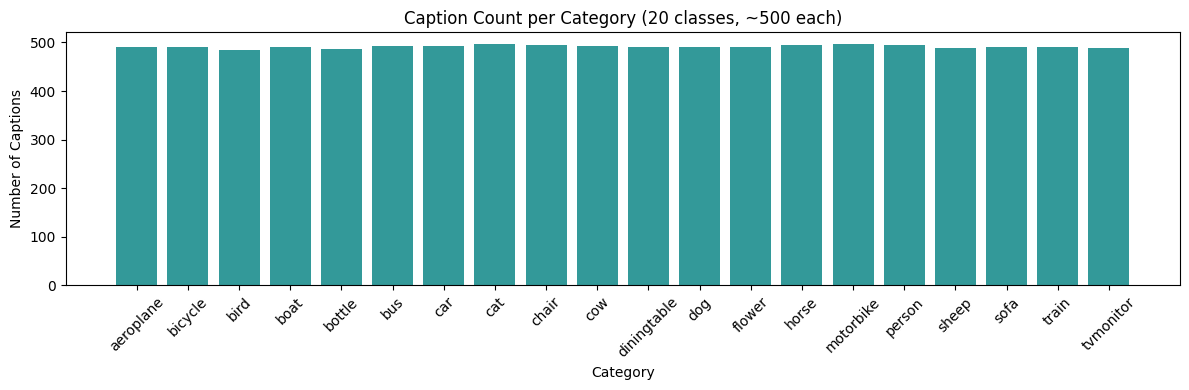


Caption length stats:
count    9825.000000
mean        6.710127
std         0.600661
min         5.000000
25%         6.000000
50%         7.000000
75%         7.000000
max        14.000000
Name: cap_len, dtype: float64


In [12]:
# Category distribution
fig, ax = plt.subplots(figsize=(12, 4))
cat_counts = df['category'].value_counts().sort_index()
ax.bar(cat_counts.index, cat_counts.values, color='teal', alpha=0.8)
ax.set_xlabel("Category")
ax.set_ylabel("Number of Captions")
ax.set_title("Caption Count per Category (20 classes, ~500 each)")
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

print(f"\nCaption length stats:")
df['cap_len'] = df['abstracted'].str.split().str.len()
print(df['cap_len'].describe())

In [13]:
# Sample for faster dev runs (set SAMPLE_FRAC=1.0 for full evaluation)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)
    print(f"Sampled {SAMPLE_FRAC*100:.0f}%: {len(df)} rows")
else:
    print(f"Using full dataset: {len(df)} rows")

print(f"Categories in sample: {df['category'].nunique()}")

Sampled 10%: 982 rows
Categories in sample: 20


## 3. Load Pretrained CLIP Model

CLIP (Contrastive Language-Image Pretraining) learns a shared embedding space where matching image-text pairs are mapped to nearby points. It consists of:
- **Image encoder** $f_\theta$ (ViT or ResNet) mapping images to vectors $\mathbf{img} = f_\theta(I) \in \mathbb{R}^d$
- **Text encoder** $g_\phi$ (Transformer) mapping captions to vectors $\mathbf{txt} = g_\phi(T) \in \mathbb{R}^d$

After L2-normalization, similarity is computed as cosine similarity: $\text{sim}(I, T) = \mathbf{img}_z^\top \mathbf{txt}_z$

In [14]:
print(f"Loading CLIP model: {MODEL_NAME} ...")
model = CLIPModel.from_pretrained(MODEL_NAME).to(device).eval()
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

# Inspect model dimensions
embed_dim = model.config.projection_dim
print(f"Model loaded successfully.")
print(f"Embedding dimension: {embed_dim}")
print(f"Vision model: {model.config.vision_config.model_type if hasattr(model.config.vision_config, 'model_type') else 'ViT'}")
print(f"Text model: Transformer")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading CLIP model: openai/clip-vit-base-patch32 ...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.
Embedding dimension: 512
Vision model: clip_vision_model
Text model: Transformer
Total parameters: 151,277,313


## 4. Encode Images & Captions

Pass all images through CLIP's image encoder and all captions through CLIP's text encoder. Embeddings are L2-normalized so that dot product = cosine similarity.

In [15]:
def encode_texts(texts, batch_size=64):
    """Encode captions into normalized CLIP text embeddings."""
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts"):
        batch = texts[i : i + batch_size]
        tok = processor.tokenizer(batch, return_tensors="pt",
                                  padding=True, truncation=True).to(device)
        with torch.no_grad():
            text_out = model.text_model(**tok)
            embs = model.text_projection(text_out.pooler_output)
            embs = torch.nn.functional.normalize(embs, dim=-1)
        all_embs.append(embs.cpu())
        del tok, text_out, embs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return torch.cat(all_embs, dim=0)


def encode_images(image_names, batch_size=32):
    """Encode images into normalized CLIP image embeddings with batching. Skips missing files."""
    embs_list, valid_idx = [], []

    # First pass: resolve all image paths
    paths_and_indices = []
    for idx, name in enumerate(image_names):
        found_path = None
        for ext in [".jpg", ".jpeg", ".JPEG", ".JPG", ".png"]:
            p = os.path.join(IMG_FOLDER, name + ext)
            if os.path.exists(p):
                found_path = p
                break
        if found_path is not None:
            paths_and_indices.append((found_path, idx))

    if not paths_and_indices:
        raise RuntimeError("No valid images found! Check IMG_FOLDER path.")

    # Second pass: encode in batches
    for batch_start in tqdm(range(0, len(paths_and_indices), batch_size),
                            desc="Encoding images"):
        batch_items = paths_and_indices[batch_start : batch_start + batch_size]
        images = []
        for fpath, idx in batch_items:
            img = Image.open(fpath).convert("RGB")
            images.append(img)

        pixel_values = processor.image_processor(images, return_tensors="pt")["pixel_values"].to(device)
        with torch.no_grad():
            vision_out = model.vision_model(pixel_values=pixel_values)
            emb = model.visual_projection(vision_out.pooler_output)
            emb = torch.nn.functional.normalize(emb, dim=-1)
        embs_list.append(emb.cpu())
        valid_idx.extend([idx for _, idx in batch_items])

        del images, pixel_values, vision_out, emb
        if (batch_start // batch_size + 1) % 10 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return torch.cat(embs_list, dim=0), valid_idx

In [16]:
# Encode captions
print("Encoding captions ...")
text_embs = encode_texts(df["abstracted"].tolist())
print(f"Text embeddings shape: {text_embs.shape}")

# Encode images
print("\nEncoding images ...")
image_embs, valid_idx = encode_images(df["image_name"].tolist())
print(f"Image embeddings shape: {image_embs.shape}")
print(f"Valid images: {len(valid_idx)} / {len(df)}")

Encoding captions ...


Encoding texts:   0%|          | 0/16 [00:00<?, ?it/s]

Text embeddings shape: torch.Size([982, 512])

Encoding images ...


Encoding images:   0%|          | 0/31 [00:00<?, ?it/s]

Image embeddings shape: torch.Size([982, 512])
Valid images: 982 / 982


In [17]:
# Keep only the valid subset (images that were found on disk)
text_embs = text_embs[valid_idx]
df_valid = df.iloc[valid_idx].reset_index(drop=True)
N = len(df_valid)
print(f"Valid subset: {N} image-caption pairs")

# Free the CLIP model — no longer needed after encoding
del model, processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("CLIP model freed from memory.")

# Compute similarity matrix on CPU (embeddings are already L2-normalized)
sim_matrix = image_embs @ text_embs.T  # (N, N) — cosine similarity
print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Diagonal (matched pairs) stats — mean: {sim_matrix.diag().mean():.4f}, "
      f"std: {sim_matrix.diag().std():.4f}")

# Save embeddings for reuse (avoids re-encoding if later cells fail)
os.makedirs(OUT_DIR, exist_ok=True)
torch.save({
    'image_embs': image_embs,
    'text_embs': text_embs,
    'sim_matrix': sim_matrix,
    'valid_idx': valid_idx,
    'model_name': MODEL_NAME,
}, os.path.join(OUT_DIR, "task2a_embeddings.pt"))
print(f"Embeddings saved to {OUT_DIR}/task2a_embeddings.pt")

Valid subset: 982 image-caption pairs
CLIP model freed from memory.
Similarity matrix shape: torch.Size([982, 982])
Diagonal (matched pairs) stats — mean: 0.3030, std: 0.0286
Embeddings saved to /jet/home/sharmar/eeg-project/task2a_results/task2a_embeddings.pt


## 5. Retrieval Metrics

### 5a. Recall@K (Section 5.4.2)

Two variants:
- **Instance-level Recall@K**: correct only if the *exact* ground-truth caption is retrieved within top-K
- **Class-aware Recall@K**: correct if *any* caption from the same semantic class is retrieved within top-K

Computed in both directions: Image→Caption and Caption→Image.

In [18]:
def recall_at_k(similarity, k):
    """Instance-level Recall@K: fraction where ground-truth index i is in top-k of row i."""
    n = similarity.shape[0]
    topk = similarity.topk(k, dim=1).indices  # (N, k)
    correct = sum(1 for i in range(n) if i in topk[i].tolist())
    return correct / n


def class_recall_at_k(similarity, classes, k):
    """Class-aware Recall@K: correct if any caption from the same class is in top-k."""
    n = similarity.shape[0]
    topk = similarity.topk(k, dim=1).indices
    correct = 0
    for i in range(n):
        if any(classes[j] == classes[i] for j in topk[i].tolist()):
            correct += 1
    return correct / n

In [19]:
classes = df_valid["category"].tolist()

# ── Image → Caption Retrieval ──
print("══ Image → Caption Retrieval ══")
recall_results = []
for k in [1, 3, 5]:
    inst = recall_at_k(sim_matrix, k)
    cls = class_recall_at_k(sim_matrix, classes, k)
    recall_results.append({"Direction": "Img→Cap", "K": k,
                           "Instance R@K": inst, "Class-aware R@K": cls})
    print(f"  R@{k}  Instance: {inst:.4f}   Class-aware: {cls:.4f}")

# ── Caption → Image Retrieval ──
print("\n══ Caption → Image Retrieval ══")
for k in [1, 3, 5]:
    inst = recall_at_k(sim_matrix.T, k)
    cls = class_recall_at_k(sim_matrix.T, classes, k)
    recall_results.append({"Direction": "Cap→Img", "K": k,
                           "Instance R@K": inst, "Class-aware R@K": cls})
    print(f"  R@{k}  Instance: {inst:.4f}   Class-aware: {cls:.4f}")

recall_df = pd.DataFrame(recall_results)
display(recall_df)

══ Image → Caption Retrieval ══
  R@1  Instance: 0.4328   Class-aware: 0.9674
  R@3  Instance: 0.6477   Class-aware: 0.9817
  R@5  Instance: 0.7475   Class-aware: 0.9847

══ Caption → Image Retrieval ══
  R@1  Instance: 0.3788   Class-aware: 0.9776
  R@3  Instance: 0.5754   Class-aware: 0.9949
  R@5  Instance: 0.6650   Class-aware: 0.9959


,Direction,K,Instance R@K,Class-aware R@K
0,Img→Cap,1,0.432790,0.967413
1,Img→Cap,3,0.647658,0.981670
2,Img→Cap,5,0.747454,0.984725
3,Cap→Img,1,0.378819,0.977597
4,Cap→Img,3,0.575356,0.994908
5,Cap→Img,5,0.664969,0.995927


### 5b. Mean Average Precision (MAP)

Three MAP variants as required by Section 5.4.3:
- **Caption-level MAP**: only the exact ground-truth caption is relevant
- **Class-aware MAP**: any caption from the same semantic class counts as relevant
- **Per-class MAP**: class-aware MAP computed separately for each of the 20 categories

In [20]:
def average_precision(sim_row, gt_relevant_set):
    """AP for a single query given a set of relevant indices."""
    ranked = sim_row.argsort(descending=True).tolist()
    hits, running_sum = 0, 0.0
    for rank, idx in enumerate(ranked, start=1):
        if idx in gt_relevant_set:
            hits += 1
            running_sum += hits / rank
    return running_sum / len(gt_relevant_set) if gt_relevant_set else 0.0


def compute_map_caption_level(similarity):
    """Caption-level MAP: only exact ground-truth caption is relevant."""
    n = similarity.shape[0]
    aps = [average_precision(similarity[i], {i}) for i in range(n)]
    return np.mean(aps)


def compute_map_class_aware(similarity, classes):
    """Class-aware MAP: any caption from the same class is relevant."""
    n = similarity.shape[0]
    class_indices = {}
    for idx, c in enumerate(classes):
        class_indices.setdefault(c, set()).add(idx)
    aps = [average_precision(similarity[i], class_indices[classes[i]]) for i in range(n)]
    return np.mean(aps)


def compute_map_per_class(similarity, classes):
    """Per-class MAP: class-aware, averaged within each class."""
    class_indices = {}
    for idx, c in enumerate(classes):
        class_indices.setdefault(c, set()).add(idx)
    per_class_map = {}
    for cls, indices in sorted(class_indices.items()):
        aps = [average_precision(similarity[i], class_indices[cls]) for i in indices]
        per_class_map[cls] = np.mean(aps)
    return per_class_map

In [21]:
# Compute all MAP variants
print("Computing MAP metrics (Image → Caption) ...")
map_caption = compute_map_caption_level(sim_matrix)
map_class = compute_map_class_aware(sim_matrix, classes)
map_per_cls = compute_map_per_class(sim_matrix, classes)

print(f"\n══ Mean Average Precision (Image → Caption) ══")
print(f"  Caption-level MAP: {map_caption:.4f}")
print(f"  Class-aware MAP:   {map_class:.4f}")
print(f"\n  Per-class MAP:")
for cls, val in sorted(map_per_cls.items(), key=lambda x: x[1], reverse=True):
    print(f"    {cls:20s}: {val:.4f}")

Computing MAP metrics (Image → Caption) ...

══ Mean Average Precision (Image → Caption) ══
  Caption-level MAP: 0.5729
  Class-aware MAP:   0.8443

  Per-class MAP:
    flower              : 0.9777
    tvmonitor           : 0.9707
    aeroplane           : 0.9645
    diningtable         : 0.9547
    bicycle             : 0.9424
    bus                 : 0.9361
    train               : 0.9361
    horse               : 0.9273
    bottle              : 0.9125
    boat                : 0.8658
    cat                 : 0.8373
    bird                : 0.8320
    sofa                : 0.7517
    chair               : 0.7456
    motorbike           : 0.7450
    cow                 : 0.7376
    dog                 : 0.7354
    sheep               : 0.7239
    car                 : 0.7046
    person              : 0.5385


## 6. Semantic Metrics: BERTScore & CLIPScore

- **BERTScore** (F1): Measures semantic similarity between retrieved and ground-truth captions using contextual embeddings from a pretrained Transformer (RoBERTa). F1 > 0.7 indicates high semantic match.
- **CLIPScore**: Cosine similarity in CLIP's embedding space. We compare distributions of matched (diagonal) vs mismatched (random off-diagonal) pairs.

In [22]:
# For each image, get the top-1 retrieved caption
best_caption_idx = sim_matrix.argmax(dim=1).cpu().tolist()
true_captions = df_valid["abstracted"].tolist()
retrieved_captions = [true_captions[j] for j in best_caption_idx]

# ── BERTScore ──
print("Computing BERTScore (this may take a minute) ...")
P, R, F1 = bert_score_fn(retrieved_captions, true_captions, lang="en", verbose=False,
                          device=device)
bert_f1 = F1.numpy()

# Free BERTScore model from GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\n══ BERTScore F1 ══")
print(f"  Mean: {bert_f1.mean():.4f}   Std: {bert_f1.std():.4f}")
print(f"  Min:  {bert_f1.min():.4f}   Max: {bert_f1.max():.4f}")
high_sem = (bert_f1 > 0.7).sum()
print(f"  F1 > 0.7:  {high_sem}/{N} ({100*high_sem/N:.1f}%)")

Computing BERTScore (this may take a minute) ...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



══ BERTScore F1 ══
  Mean: 0.9547   Std: 0.0447
  Min:  0.8524   Max: 1.0000
  F1 > 0.7:  982/982 (100.0%)


In [23]:
# ── CLIPScore distributions ──
sim_np = sim_matrix.cpu().numpy()

# Matched (diagonal): similarity of image_i with its true caption_i
clip_score_matched = np.array([sim_np[i, i] for i in range(N)])

# Best retrieved: similarity of image_i with its top-1 retrieved caption
clip_score_retrieved = np.array([sim_np[i, best_caption_idx[i]] for i in range(N)])

# Random mismatched: similarity with a random non-matching caption
# Use efficient random offset instead of building full exclusion lists
rng = np.random.RandomState(SEED)
random_offsets = rng.randint(1, N, size=N)
random_idx = (np.arange(N) + random_offsets) % N
clip_score_random = sim_np[np.arange(N), random_idx]

print(f"══ CLIPScore Statistics ══")
print(f"  Matched   — mean: {clip_score_matched.mean():.4f}, std: {clip_score_matched.std():.4f}")
print(f"  Retrieved — mean: {clip_score_retrieved.mean():.4f}, std: {clip_score_retrieved.std():.4f}")
print(f"  Random    — mean: {clip_score_random.mean():.4f}, std: {clip_score_random.std():.4f}")

══ CLIPScore Statistics ══
  Matched   — mean: 0.3030, std: 0.0286
  Retrieved — mean: 0.3136, std: 0.0243
  Random    — mean: 0.1459, std: 0.0429


## 7. Visualizations

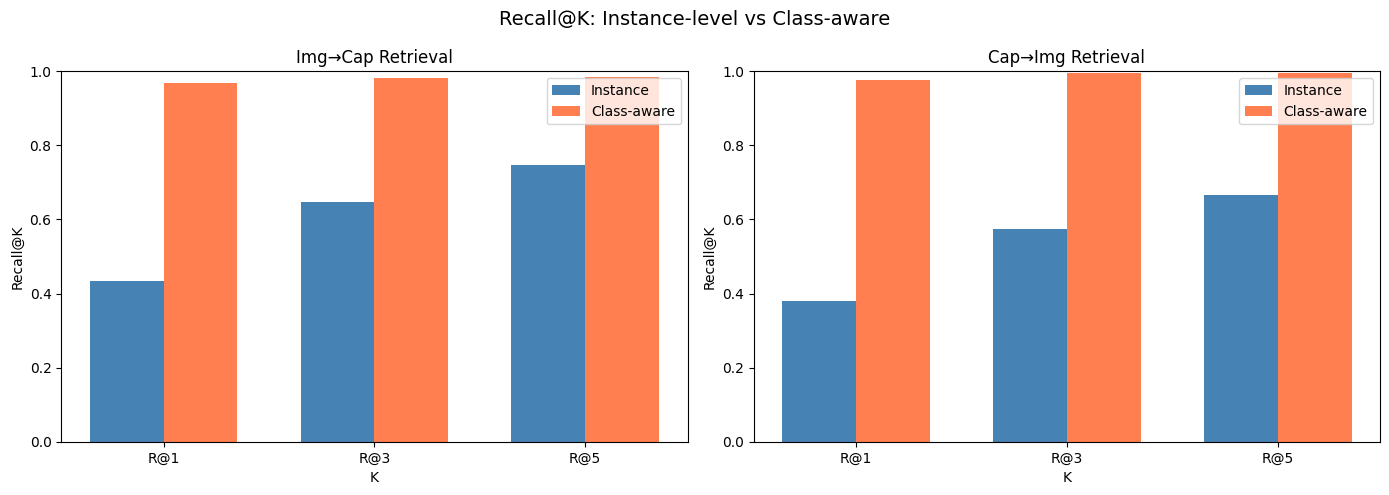

In [24]:
# ── Plot 1: Recall@K comparison bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, direction in enumerate(["Img→Cap", "Cap→Img"]):
    ax = axes[ax_idx]
    sub_df = recall_df[recall_df["Direction"] == direction]
    x = np.arange(len(sub_df))
    width = 0.35
    ax.bar(x - width/2, sub_df["Instance R@K"], width, label="Instance", color="steelblue")
    ax.bar(x + width/2, sub_df["Class-aware R@K"], width, label="Class-aware", color="coral")
    ax.set_xlabel("K")
    ax.set_ylabel("Recall@K")
    ax.set_title(f"{direction} Retrieval")
    ax.set_xticks(x)
    ax.set_xticklabels([f"R@{k}" for k in sub_df["K"]])
    ax.legend()
    ax.set_ylim(0, 1)

fig.suptitle("Recall@K: Instance-level vs Class-aware", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "recall_at_k.png"), dpi=150)
plt.show()

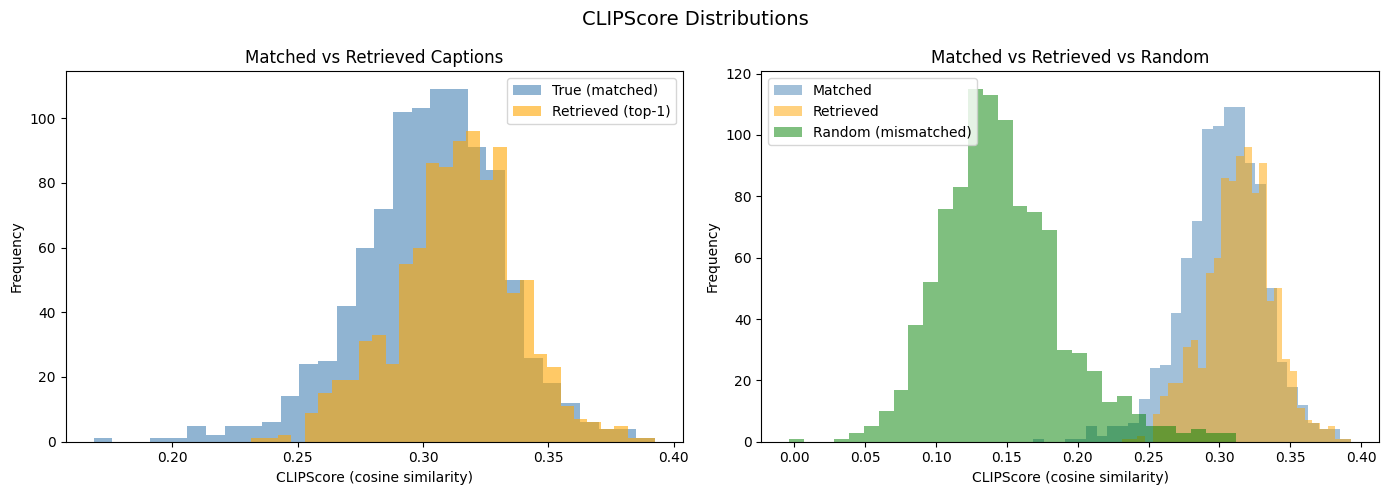

In [25]:
# ── Plot 2: CLIPScore — Matched vs Retrieved vs Random ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2a: Matched vs Retrieved
ax = axes[0]
ax.hist(clip_score_matched, bins=30, alpha=0.6, label="True (matched)", color="steelblue")
ax.hist(clip_score_retrieved, bins=30, alpha=0.6, label="Retrieved (top-1)", color="orange")
ax.set_xlabel("CLIPScore (cosine similarity)")
ax.set_ylabel("Frequency")
ax.set_title("Matched vs Retrieved Captions")
ax.legend()

# 2b: All three
ax = axes[1]
ax.hist(clip_score_matched, bins=30, alpha=0.5, label="Matched", color="steelblue")
ax.hist(clip_score_retrieved, bins=30, alpha=0.5, label="Retrieved", color="orange")
ax.hist(clip_score_random, bins=30, alpha=0.5, label="Random (mismatched)", color="green")
ax.set_xlabel("CLIPScore (cosine similarity)")
ax.set_ylabel("Frequency")
ax.set_title("Matched vs Retrieved vs Random")
ax.legend()

fig.suptitle("CLIPScore Distributions", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "clipscore_distributions.png"), dpi=150)
plt.show()

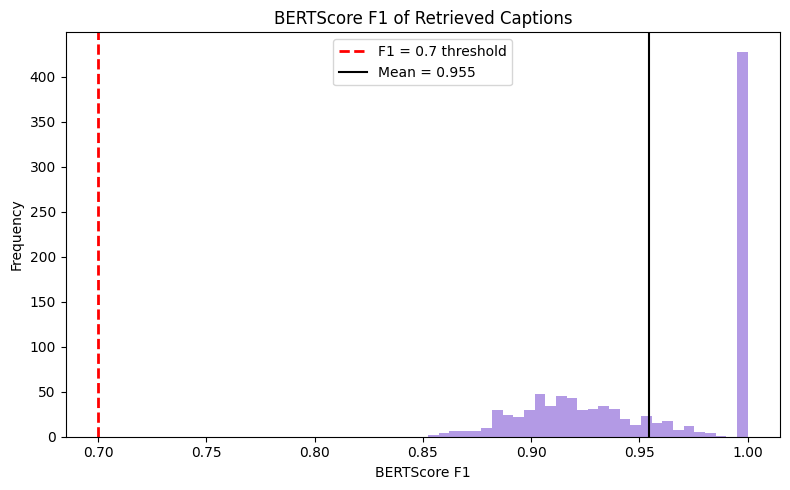

In [26]:
# ── Plot 3: BERTScore F1 histogram ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bert_f1, bins=30, alpha=0.7, color="mediumpurple")
ax.axvline(0.7, color="red", linestyle="--", linewidth=2, label="F1 = 0.7 threshold")
ax.axvline(bert_f1.mean(), color="black", linestyle="-", linewidth=1.5,
           label=f"Mean = {bert_f1.mean():.3f}")
ax.set_xlabel("BERTScore F1")
ax.set_ylabel("Frequency")
ax.set_title("BERTScore F1 of Retrieved Captions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bertscore_histogram.png"), dpi=150)
plt.show()

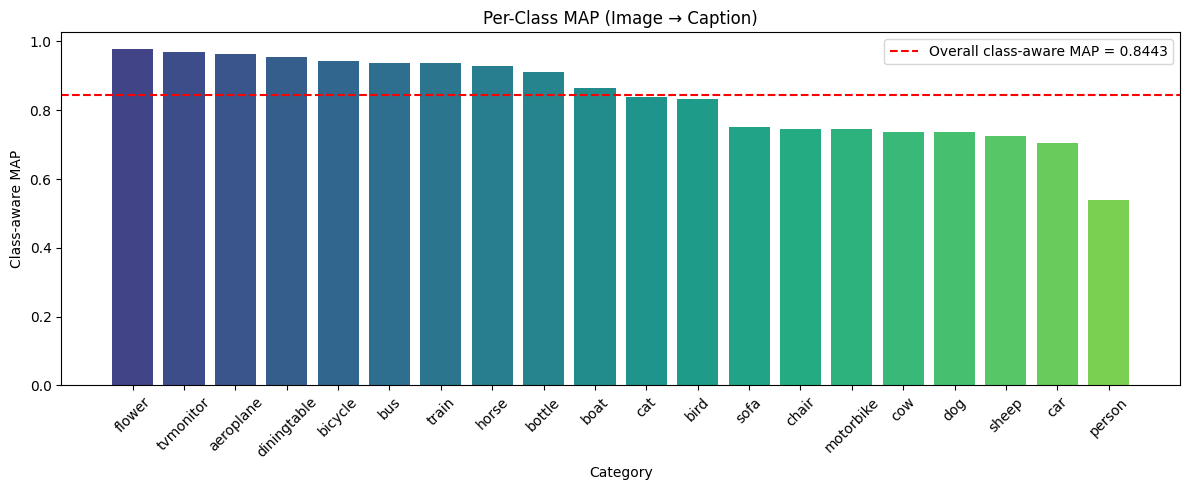

In [27]:
# ── Plot 4: Per-class MAP bar chart ──
fig, ax = plt.subplots(figsize=(12, 5))
sorted_cls = sorted(map_per_cls.items(), key=lambda x: x[1], reverse=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_cls)))
ax.bar([c for c, _ in sorted_cls], [v for _, v in sorted_cls], color=colors)
ax.axhline(map_class, color="red", linestyle="--", linewidth=1.5,
           label=f"Overall class-aware MAP = {map_class:.4f}")
ax.set_xlabel("Category")
ax.set_ylabel("Class-aware MAP")
ax.set_title("Per-Class MAP (Image → Caption)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "per_class_map.png"), dpi=150)
plt.show()

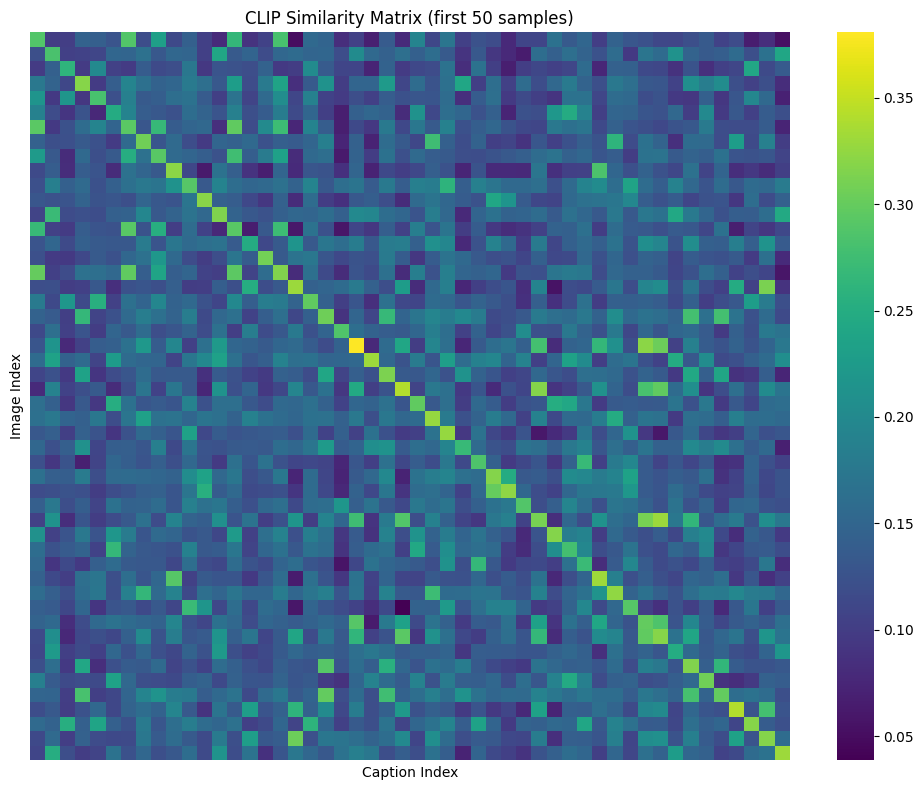

In [28]:
# ── Plot 5: Similarity matrix heatmap (subset) ──
# Show first 50 samples to visualize block-diagonal structure
n_show = min(50, N)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_np[:n_show, :n_show], cmap="viridis", ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_xlabel("Caption Index")
ax.set_ylabel("Image Index")
ax.set_title(f"CLIP Similarity Matrix (first {n_show} samples)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "similarity_matrix.png"), dpi=150)
plt.show()

## 8. Qualitative Retrieval Examples

Show concrete examples of Image→Caption and Caption→Image retrieval to illustrate CLIP's behavior on our dataset.

In [29]:
# ── Qualitative examples: show top-3 retrieved captions per image ──
n_examples = min(10, N)
print("══ Qualitative Retrieval Examples ══\n")

for i in range(n_examples):
    true_img = df_valid.loc[i, "image_name"]
    true_cap = df_valid.loc[i, "abstracted"]
    true_cls = df_valid.loc[i, "category"]

    # Top-3 retrieved captions for this image
    top3_idx = sim_matrix[i].topk(3).indices.cpu().tolist()

    # Best image for this caption (caption→image direction)
    best_img_idx = sim_matrix[:, i].argmax().item()
    ret_img = df_valid.loc[best_img_idx, "image_name"]

    match_emoji = "+" if best_caption_idx[i] == i else "-"

    print(f"  Example {i+1} [{match_emoji}]")
    print(f"  {'─'*60}")
    print(f"  Image:          {true_img}  [{true_cls}]")
    print(f"  True Caption:   {true_cap}")
    print(f"  Retrieved Top-3:")
    for rank, j in enumerate(top3_idx, 1):
        ret_cap = true_captions[j]
        ret_cls = df_valid.loc[j, "category"]
        marker = " <<< MATCH" if j == i else ""
        print(f"    {rank}. [{ret_cls}] {ret_cap}{marker}")
    print(f"  Caption→Image:  {ret_img}")
    print()

══ Qualitative Retrieval Examples ══

  Example 1 [-]
  ────────────────────────────────────────────────────────────
  Image:          000333  [train]
  True Caption:   Freight train winding through rural landscape
  Retrieved Top-3:
    1. [train] Freight train traveling along rural tracks
    2. [train] Freight train passing through a small town
    3. [train] Freight train passing through mountain valley station
  Caption→Image:  2011_000012

  Example 2 [+]
  ────────────────────────────────────────────────────────────
  Image:          2010_004832  [dog]
  True Caption:   Dog near wooden table and Christmas tree
  Retrieved Top-3:
    1. [dog] Dog near wooden table and Christmas tree <<< MATCH
    2. [dog] Dog with a green collar indoors
    3. [dog] Dog standing on a rug near sofa
  Caption→Image:  2010_004832

  Example 3 [-]
  ────────────────────────────────────────────────────────────
  Image:          n04483307_9871  [boat]
  True Caption:   Boat anchored near a cloudy shore

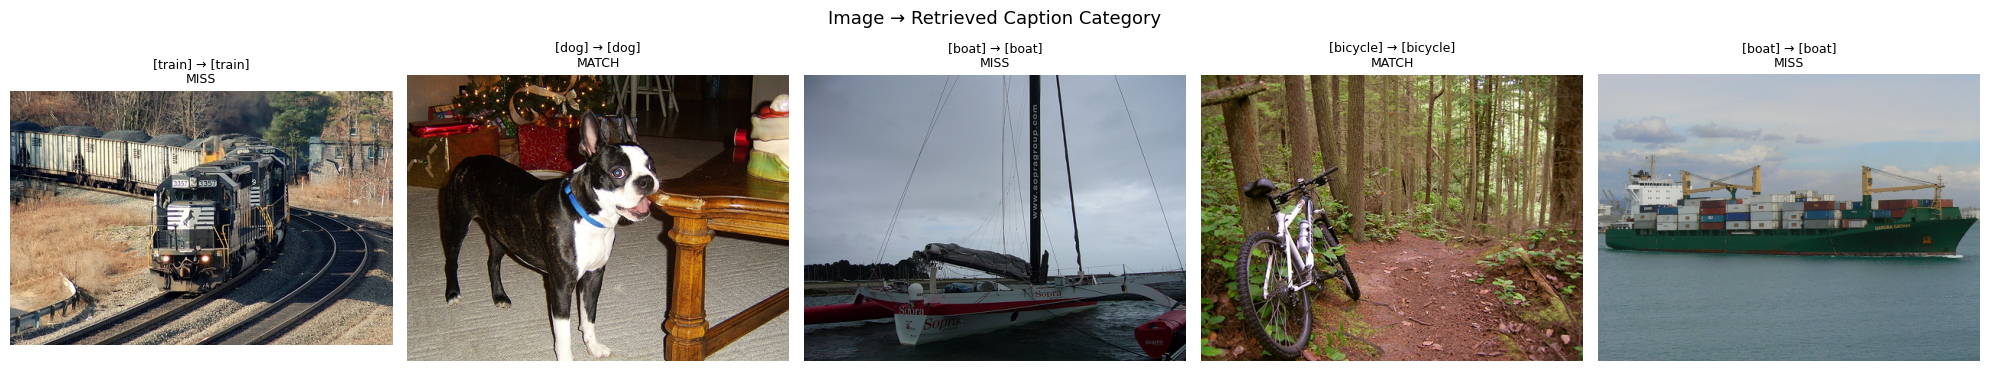

In [30]:
# ── Visual examples: show image alongside retrieved caption ──
n_visual = min(5, N)
fig, axes = plt.subplots(1, n_visual, figsize=(4 * n_visual, 4))
if n_visual == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    img_name = df_valid.loc[i, "image_name"]
    true_cls = df_valid.loc[i, "category"]
    ret_cap = retrieved_captions[i]
    ret_cls = df_valid.loc[best_caption_idx[i], "category"]

    # Try to load and display image
    found = False
    for ext in [".jpg", ".jpeg", ".JPEG", ".JPG", ".png"]:
        p = os.path.join(IMG_FOLDER, img_name + ext)
        if os.path.exists(p):
            img = Image.open(p).convert("RGB")
            ax.imshow(img)
            found = True
            break
    if not found:
        ax.text(0.5, 0.5, "Image\nnot found", ha='center', va='center', fontsize=12)

    match = "MATCH" if best_caption_idx[i] == i else "MISS"
    ax.set_title(f"[{true_cls}] → [{ret_cls}]\n{match}", fontsize=9)
    ax.axis('off')

fig.suptitle("Image → Retrieved Caption Category", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "qualitative_examples.png"), dpi=150)
plt.show()

## 9. Per-Category Analysis

Break down retrieval performance by category to understand which object classes CLIP handles well vs poorly. This analysis will serve as a baseline comparison for Task 2B (EEG-Caption Retrieval).

In [31]:
# Per-category BERTScore and CLIPScore
per_cat_stats = []
for cat in sorted(df_valid['category'].unique()):
    mask = df_valid['category'] == cat
    idxs = mask[mask].index.tolist()

    cat_bert = bert_f1[idxs]
    cat_clip_matched = clip_score_matched[idxs]
    cat_clip_retrieved = clip_score_retrieved[idxs]

    # Per-cat instance R@1
    correct = sum(1 for i in idxs if best_caption_idx[i] == i)

    per_cat_stats.append({
        'category': cat,
        'count': len(idxs),
        'R@1_instance': correct / len(idxs),
        'MAP': map_per_cls.get(cat, 0),
        'BERTScore_F1_mean': cat_bert.mean(),
        'CLIPScore_matched_mean': cat_clip_matched.mean(),
        'CLIPScore_retrieved_mean': cat_clip_retrieved.mean(),
    })

per_cat_df = pd.DataFrame(per_cat_stats).sort_values('MAP', ascending=False)
display(per_cat_df.round(4))

,category,count,R@1_instance,MAP,BERTScore_F1_mean,CLIPScore_matched_mean,CLIPScore_retrieved_mean
12,flower,57,0.2807,0.9777,0.9445,0.3160,0.3317
19,tvmonitor,50,0.2800,0.9707,0.9326,0.3121,0.3283
0,aeroplane,55,0.2727,0.9645,0.9542,0.2830,0.2942
10,diningtable,59,0.2881,0.9547,0.9510,0.3134,0.3280
1,bicycle,56,0.4286,0.9424,0.9496,0.3099,0.3193
5,bus,49,0.3469,0.9361,0.9495,0.3073,0.3186
18,train,48,0.4792,0.9361,0.9477,0.3052,0.3145
13,horse,55,0.3273,0.9273,0.9529,0.3054,0.3180
4,bottle,39,0.6667,0.9125,0.9715,0.3155,0.3226
3,boat,45,0.1778,0.8658,0.9356,0.2935,0.3066


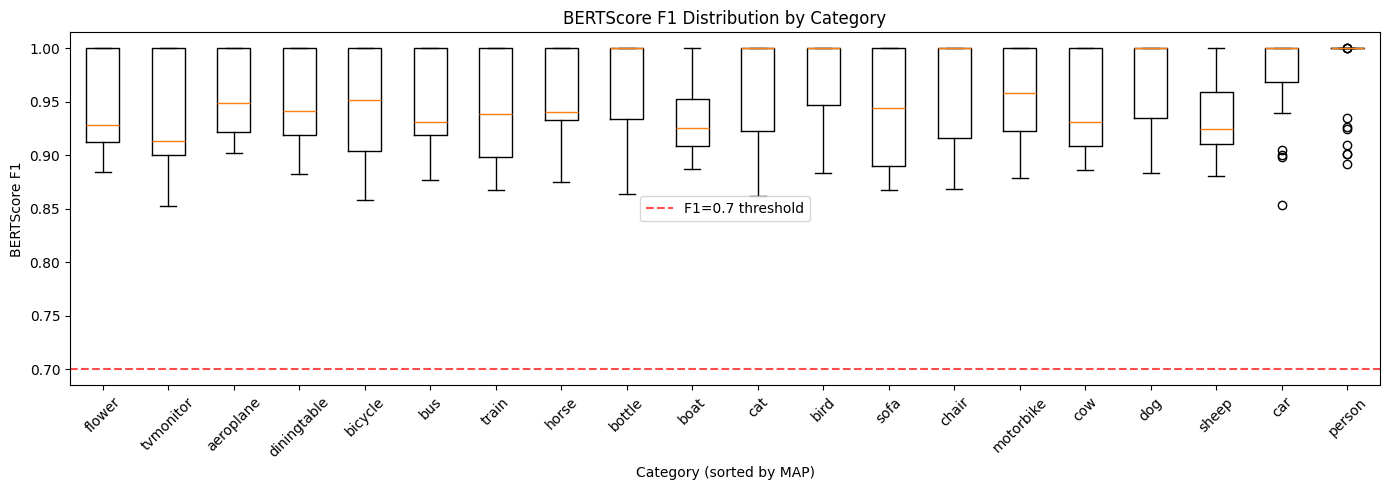

In [32]:
# ── Plot 6: Per-category BERTScore boxplot ──
fig, ax = plt.subplots(figsize=(14, 5))
cat_order = per_cat_df['category'].tolist()  # sorted by MAP
cat_bert_data = [bert_f1[df_valid['category'] == cat] for cat in cat_order]
ax.boxplot(cat_bert_data, labels=cat_order, vert=True)
ax.axhline(0.7, color='red', linestyle='--', alpha=0.7, label='F1=0.7 threshold')
ax.set_xlabel("Category (sorted by MAP)")
ax.set_ylabel("BERTScore F1")
ax.set_title("BERTScore F1 Distribution by Category")
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bertscore_per_category.png"), dpi=150)
plt.show()

## 10. Summary & Save Results

Consolidate all results into a summary table and save artifacts for downstream use in Task 2B.

In [33]:
# ── Summary table ──
print("══════════════════════════════════════════════════")
print("     TASK 2A RESULTS SUMMARY")
print(f"     Model: {MODEL_NAME}")
print(f"     Dataset: {N} image-caption pairs")
print("══════════════════════════════════════════════════")

print("\n── Recall@K ──")
display(recall_df)

print(f"\n── MAP ──")
print(f"  Caption-level MAP: {map_caption:.4f}")
print(f"  Class-aware MAP:   {map_class:.4f}")

print(f"\n── BERTScore F1 ──")
print(f"  Mean: {bert_f1.mean():.4f}  |  Std: {bert_f1.std():.4f}")
print(f"  F1 > 0.7: {high_sem}/{N} ({100*high_sem/N:.1f}%)")

print(f"\n── CLIPScore ──")
print(f"  Matched:   {clip_score_matched.mean():.4f} +/- {clip_score_matched.std():.4f}")
print(f"  Retrieved: {clip_score_retrieved.mean():.4f} +/- {clip_score_retrieved.std():.4f}")
print(f"  Random:    {clip_score_random.mean():.4f} +/- {clip_score_random.std():.4f}")

══════════════════════════════════════════════════
     TASK 2A RESULTS SUMMARY
     Model: openai/clip-vit-base-patch32
     Dataset: 982 image-caption pairs
══════════════════════════════════════════════════

── Recall@K ──


,Direction,K,Instance R@K,Class-aware R@K
0,Img→Cap,1,0.432790,0.967413
1,Img→Cap,3,0.647658,0.981670
2,Img→Cap,5,0.747454,0.984725
3,Cap→Img,1,0.378819,0.977597
4,Cap→Img,3,0.575356,0.994908
5,Cap→Img,5,0.664969,0.995927



── MAP ──
  Caption-level MAP: 0.5729
  Class-aware MAP:   0.8443

── BERTScore F1 ──
  Mean: 0.9547  |  Std: 0.0447
  F1 > 0.7: 982/982 (100.0%)

── CLIPScore ──
  Matched:   0.3030 +/- 0.0286
  Retrieved: 0.3136 +/- 0.0243
  Random:    0.1459 +/- 0.0429


In [34]:
# ── Save detailed results CSV ──
results_df = pd.DataFrame({
    "image_name": df_valid["image_name"],
    "category": df_valid["category"],
    "true_caption": true_captions,
    "retrieved_caption": retrieved_captions,
    "CLIPScore_matched": clip_score_matched,
    "CLIPScore_retrieved": clip_score_retrieved,
    "CLIPScore_random": clip_score_random,
    "BERTScore_F1": bert_f1,
})
results_df.to_csv(os.path.join(OUT_DIR, "task2a_results.csv"), index=False)

# Save per-category summary
per_cat_df.to_csv(os.path.join(OUT_DIR, "task2a_per_category.csv"), index=False)

print(f"\nAll results saved to: {OUT_DIR}/")
print("Files:")
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f"  {f:40s} ({size/1024:.1f} KB)")


All results saved to: /jet/home/sharmar/eeg-project/task2a_results/
Files:
  bertscore_histogram.png                  (41.1 KB)
  bertscore_per_category.png               (86.5 KB)
  clipscore_distributions.png              (62.3 KB)
  per_class_map.png                        (77.9 KB)
  qualitative_examples.png                 (2563.0 KB)
  recall_at_k.png                          (45.5 KB)
  similarity_matrix.png                    (49.2 KB)
  task2a_embeddings.pt                     (7699.7 KB)
  task2a_per_category.csv                  (1.6 KB)
  task2a_results.csv                       (135.3 KB)


## Analysis Notes

**What these results tell us about CLIP's retrieval behavior:**

- **Instance vs Class-aware R@K gap**: The gap between instance-level and class-aware Recall@K reveals how often CLIP retrieves semantically similar (same-class) captions even when it misses the exact match. A large gap suggests CLIP captures category-level semantics well but struggles with fine-grained instance discrimination.

- **BERTScore F1**: High BERTScore (> 0.7) for retrieved captions indicates that even "wrong" retrievals are often semantically close to the ground truth, confirming CLIP's embeddings capture meaningful visual-linguistic correspondences.

- **CLIPScore distributions**: The separation between matched and random distributions shows the discriminative power of CLIP's embedding space. Overlap between matched and retrieved distributions is expected when retrieval works well.

- **Per-class MAP variation**: Categories with distinctive visual features (e.g., airplane, bicycle) typically achieve higher MAP than visually similar or generic categories, reflecting the difficulty of fine-grained retrieval.

**Connection to Task 2B**: These metrics establish the *upper bound* for retrieval using actual images. In Task 2B, we replace image embeddings with EEG-derived embeddings and compare against these baselines to quantify how much information is lost when decoding from brain signals.